# 05 — Explicabilidad

**Fase 1E.** ¿Qué impulsa el riesgo? ¿Qué es protector? Combinamos **SHAP** (atribución por paciente), **permutation importance** (model-agnóstica) y **partial dependence** (forma del efecto + interacciones).

In [1]:
# --- Setup: rutas y utilidades de presentación ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BR / "src"))
sys.path.insert(0, str(BR.parent / "src"))
from predia_brfss import config, codebook

RES = BR / "results"
def show(p, w=None):
    display(Image(filename=str(p), width=w))
def table(csv, **kw):
    return pd.read_csv(csv, **kw)
def load(j):
    return json.load(open(j))
pd.set_option("display.max_columns", 40)
print("Entorno listo:", BR)


Entorno listo: /home/wowo/Descargas/predia/ml-research/brfss


## SHAP — importancia global y dirección

In [2]:
ex = load(RES/'explainability'/'explainability.json')
print('Modelo de riesgo:', ex['risk_model'], '| SHAP vía:', ex['shap_model'])
table(RES/'explainability'/'shap_global_importance.csv')

Modelo de riesgo: xgboost | SHAP vía: xgboost


,feature,mean_abs_shap,label,direction
0,GenHlth,0.58394,Salud general percibida,riesgo
1,HighBP,0.45887,Hipertensión arterial,riesgo
2,BMI,0.39509,Índice de masa corporal (IMC),riesgo
3,Age,0.35878,Grupo etario,riesgo
4,HighChol,0.26328,Colesterol alto,riesgo
5,Income,0.11465,Nivel de ingreso,protector
6,Sex,0.09535,"Sexo (0=mujer, 1=hombre)",riesgo
7,HeartDiseaseorAttack,0.05411,Cardiopatía coronaria o infarto,riesgo
8,CholCheck,0.04987,Chequeo de colesterol en 5 años,riesgo
9,DiffWalk,0.04893,Dificultad para caminar/subir escaleras,riesgo


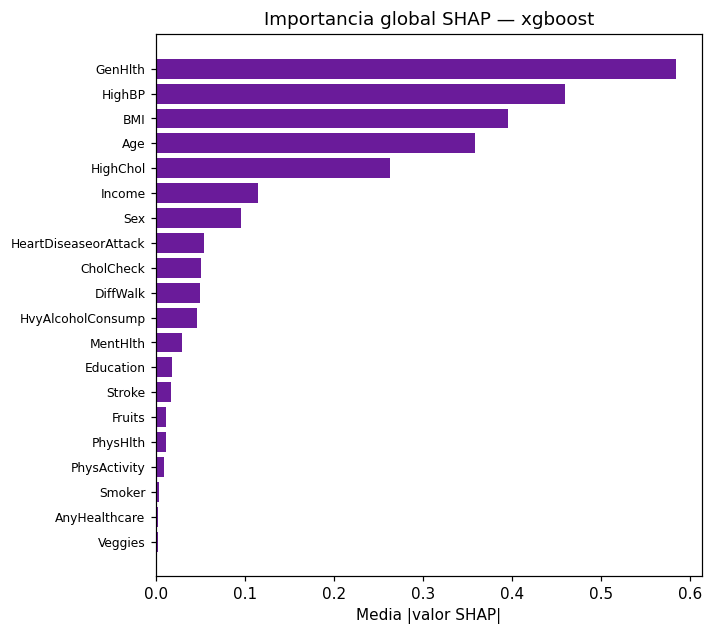

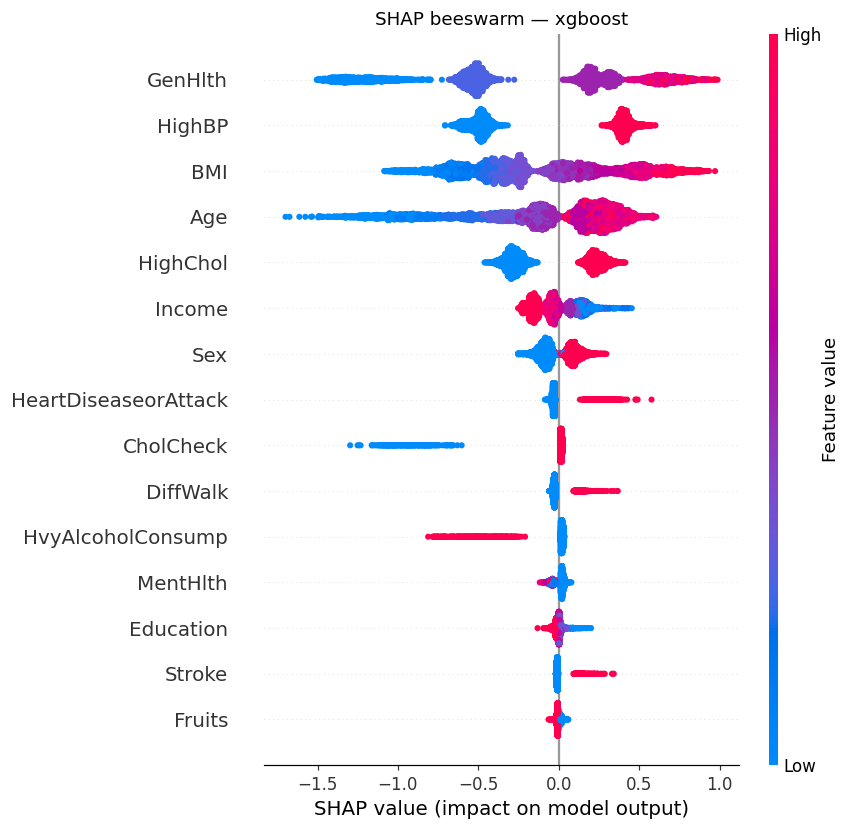

In [3]:
show(RES/'explainability'/'shap_bar.png')
show(RES/'explainability'/'shap_beeswarm.png')

## Permutation importance

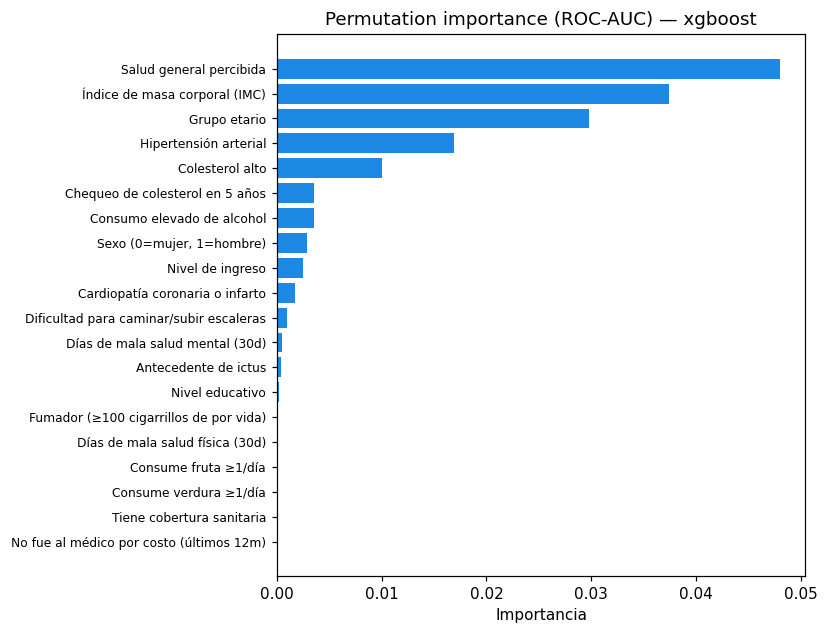

In [4]:
show(RES/'explainability'/'permutation_importance.png')

## Partial dependence e interacciones

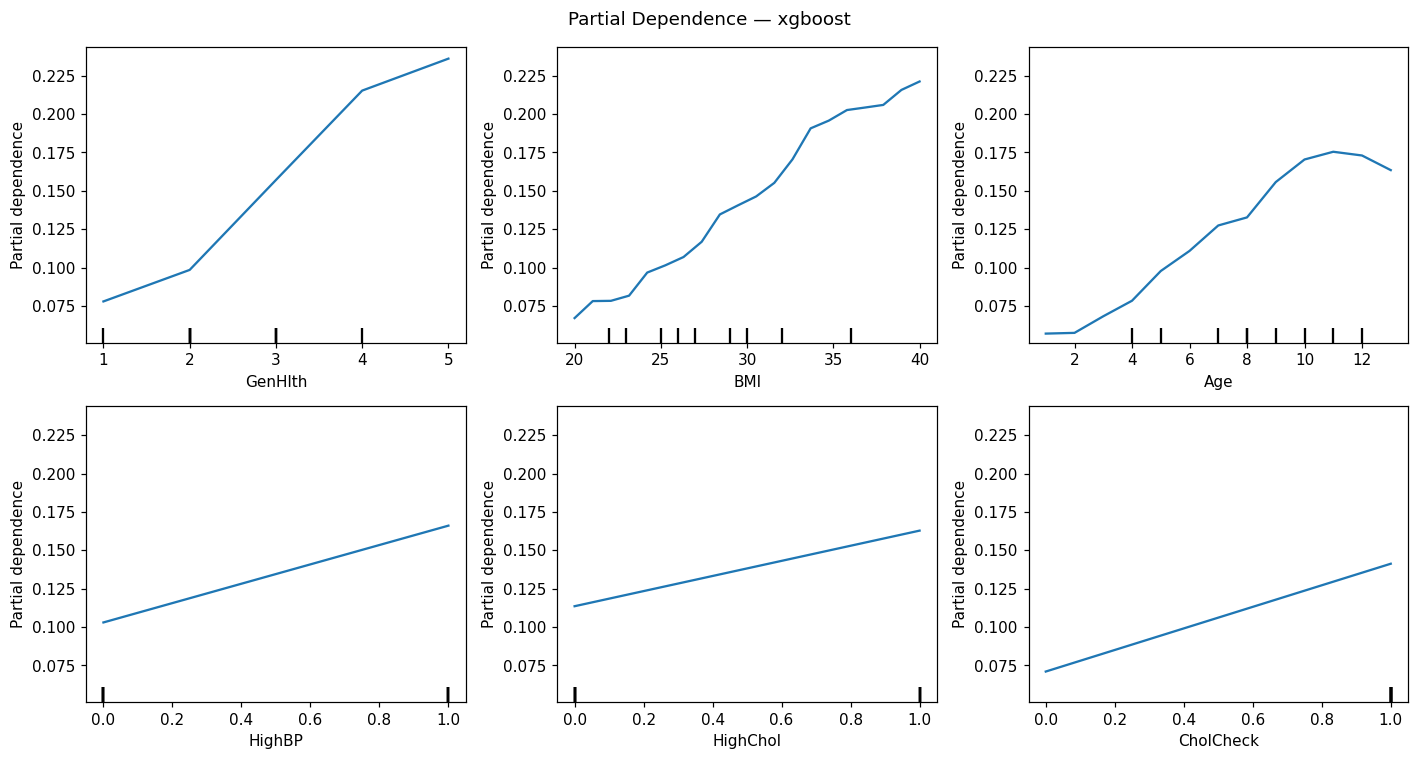

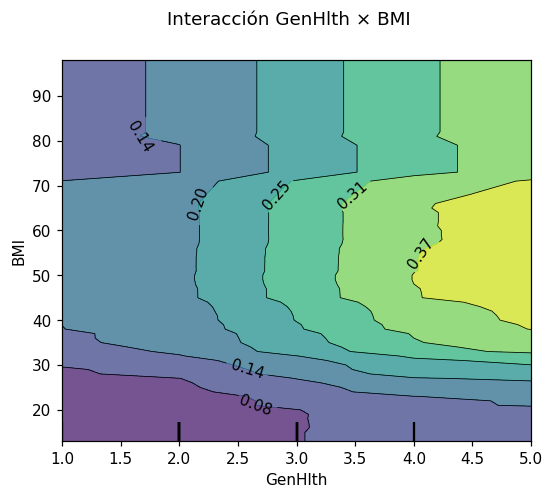

In [5]:
show(RES/'explainability'/'partial_dependence.png')
show(RES/'explainability'/'interaction_pdp.png')

## Factores de riesgo vs protectores

In [6]:
print('— Factores de RIESGO —')
for g in ex['risk_factors']: print(' ', g['label'])
print('\n— Factores PROTECTORES —')
for g in ex['protective_factors']: print(' ', g['label'])

— Factores de RIESGO —
  Salud general percibida
  Hipertensión arterial
  Índice de masa corporal (IMC)
  Grupo etario
  Colesterol alto
  Sexo (0=mujer, 1=hombre)
  Cardiopatía coronaria o infarto
  Chequeo de colesterol en 5 años

— Factores PROTECTORES —
  Nivel de ingreso
  Consumo elevado de alcohol
  Días de mala salud mental (30d)
  Nivel educativo
  Consume fruta ≥1/día
  Actividad física (últimos 30 días)
  Fumador (≥100 cigarrillos de por vida)
  Consume verdura ≥1/día


### Conclusiones Fase 1E
- Coinciden SHAP y permutation: **salud general percibida, hipertensión, IMC, edad, colesterol y dificultad para caminar** dominan el riesgo.
- **Actividad física, consumo de fruta/verdura e ingresos altos** actúan como protectores.
- Las PDP muestran efectos monótonos (riesgo ↑ con IMC y edad) e interacciones plausibles, dando **transparencia clínica** al motor.